In [1]:
import numpy as np

length_path = "../lengths_pr.npy"
lengths = np.load(length_path, allow_pickle=True).item()
L = []
for key in lengths:
    L.append(lengths[key])
L = np.array(L)
len(L)

8274782

8223417 8274782


<Axes: ylabel='Count'>

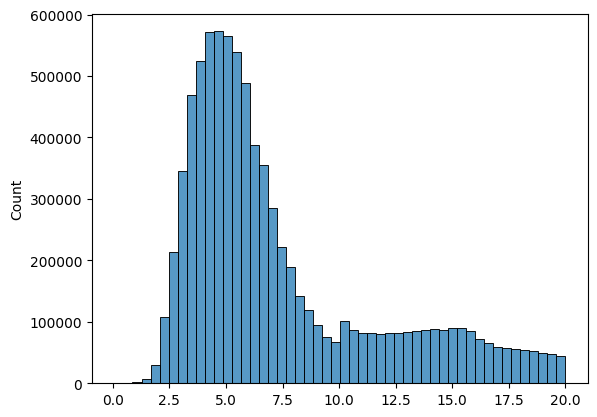

In [ ]:
import seaborn as sns

L_filtered = L[L < 20]
print(len(L_filtered), len(L))
sns.histplot(L_filtered, bins=50)

In [33]:
import random

random.seed(42)

from tqdm import tqdm
import heapq


def _generate_packs(L, use_packing=0.5, pack_limit=20, max_duration=20):
    # Filter and setup
    L_filtered = {k: v for k, v in L.items() if v <= max_duration}
    all_keys = list(L_filtered.keys())
    random.shuffle(all_keys)

    num_to_pack = int(len(all_keys) * use_packing)
    to_pack, standalone = all_keys[:num_to_pack], all_keys[num_to_pack:]
    final_packs = [[k] for k in standalone]

    if to_pack:
        # Sort descending to perform First-Fit Decreasing
        sorted_keys = sorted(to_pack, key=lambda k: L_filtered[k], reverse=True)

        # bin_contents: list of lists [key1, key2...]
        # heap: tracks (current_total_duration, bin_index)
        # Using a min-heap allows us to find the bin with the most space in O(log N)
        bin_contents = []
        heap = []
        for k in tqdm(sorted_keys, desc="Packing"):
            dur = L_filtered[k]
            # Check the bin with the smallest current duration (most available space)
            if heap and (heap[0][0] + dur + 0.3 <= pack_limit):
                curr_dur, idx = heapq.heappop(heap)
                bin_contents[idx].append(k)
                heapq.heappush(heap, (curr_dur + dur + 0.3, idx))
            else:
                # Create new bin
                idx = len(bin_contents)
                bin_contents.append([k])
                heapq.heappush(heap, (dur, idx))

        final_packs.extend(bin_contents)

    return final_packs


packs = _generate_packs(lengths, use_packing=0.7, pack_limit=20, max_duration=20)

Packing: 100%|██████████| 5785725/5785725 [00:18<00:00, 320985.13it/s]


In [34]:
len(packs)

4712294

In [35]:
len(lengths)

8274782

<Axes: ylabel='Count'>

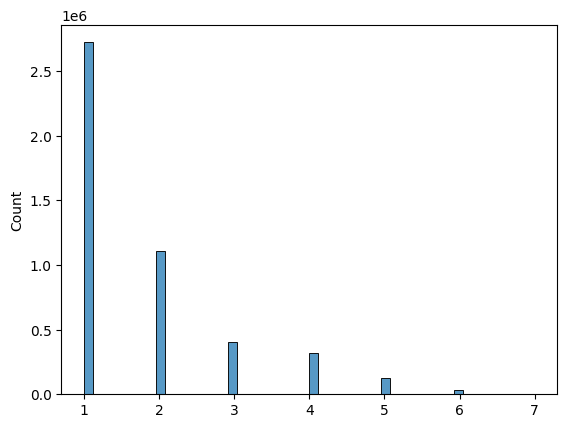

In [36]:
ll = [len(lll) for lll in packs]
durationsll = [sum([lengths[k] for k in lll]) for lll in packs]
sns.histplot(ll, bins=50)

<Axes: ylabel='Count'>

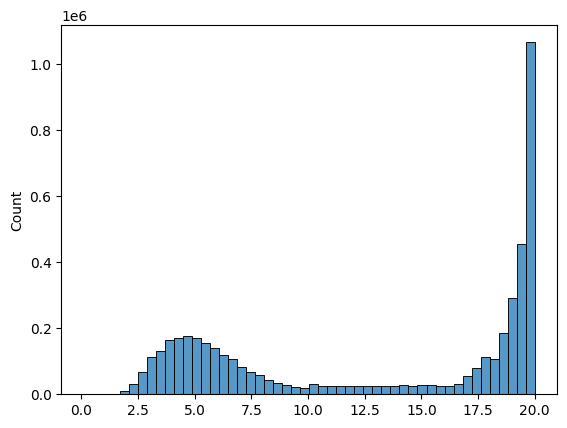

In [37]:
sns.histplot(durationsll, bins=50)